# Titanic: code prep

Run this notebook from the session-3 folder. Print the available columns, then put three predictor names in `INDEPENDENT_VARIABLES` and rerun the cells. Errors are measured on held-out data; lower values mean better predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Pclass is the passenger's ticket class:
# 1 = First class
# 2 = Second class
# 3 = Third class
# I chose one-hot encoding intuitively so the model could differenciate between classes  
# independent of a specific ascending order
# Without one-hot encoding percentage error goes up by 10% 
# The other variables are already numeric counts:
# Parch = Number of parents and children aboard.
# SibSp = Number of siblings and spouses aboard.
# I figured that having more family aboard might indicate a wealthier passenger
# and a higher fare. 
INDEPENDENT_VARIABLES = ["Pclass", "Parch", "SibSp"]
TARGET = "Fare"
TEST_SIZE = 0.33
RANDOM_STATE = 101

In [2]:
titanic = pd.read_csv("../data/titanic/train.csv")

In [3]:
print(titanic.columns.to_numpy())

['PassengerId' 'Survived' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch'
 'Ticket' 'Fare' 'Cabin' 'Embarked']


Keep the selected predictors and fare, and drop rows missing any of these values. One-hot encode Pclass, using first class as the reference category. Parch and SibSp remain numeric counts.

In [4]:
data = titanic[INDEPENDENT_VARIABLES + [TARGET]].dropna()
data.head()

,Pclass,Parch,SibSp,Fare
0,3,0,1,7.2500
1,1,0,1,71.2833
2,3,0,0,7.9250
3,1,0,1,53.1000
4,3,0,0,8.0500


In [ ]:
# get_dummies enables one-hot encoding 
X = pd.get_dummies(data[INDEPENDENT_VARIABLES], columns=["Pclass"], drop_first=True, dtype=int)
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 9.96, 5.77,-55.54,-64.71]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Parch','SibSp','Pclass_2','Pclass_3']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,70.93
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [6]:
pred = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, pred))
print("Mean Squared Error:", mean_squared_error(y_test, pred))
print("Root Mean Squared Error:", mean_squared_error(y_test, pred) ** 0.5)

percentage_error = abs(y_test - pred).sum() / abs(y_test).sum() * 100
print(f"Percentage error (Lower is better): {percentage_error:.2f}%")

Mean Absolute Error: 17.421753094290054
Mean Squared Error: 2266.9067476844566
Root Mean Squared Error: 47.612044145199825
Percentage error (Lower is better): 49.08%


In the code cell below, use a visualization library such as pyplot or seaborn to create a visualization of the 3 variable model you created above, showing the line of best fit.

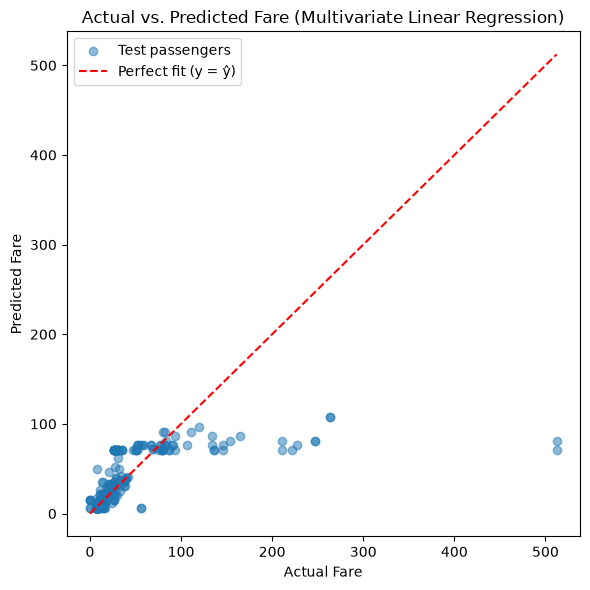

In [46]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred, alpha=0.5, label="Test passengers")

lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, color="red", linestyle="--", label="Perfect fit (y = ŷ)")

ax.set_xlabel("Actual Fare")
ax.set_ylabel("Predicted Fare")
ax.set_title("Actual vs. Predicted Fare (Multivariate Linear Regression)")
ax.legend()
plt.tight_layout()
plt.savefig("fare_fit.png", dpi=150)
plt.show()